# 01 · Data Exploration (EDA)
### Load, clean, and explore 25 years of FAOSTAT crop data for Sierra Leone

**Author:** Ibrahim Denis Fofanah — Pace University | RiseAfrica Foundation for STEM and Innovation
**Project:** Machine Learning Approaches to Crop Yield Prediction and Post-Harvest Loss Reduction — Evidence from Sierra Leone

---

In [1]:
# ── Setup & project-root anchoring ────────────────────────────────────────────
import sys, os, warnings

# Resolve paths whether launched from repo root or from notebooks/
if not os.path.exists('data/raw') and os.path.exists('../data/raw'):
    os.chdir('..')
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)

for d in ['data/processed', 'outputs/figures', 'outputs/models', 'outputs/reports']:
    os.makedirs(d, exist_ok=True)

print(f'Working directory: {os.getcwd()}')

Working directory: /Users/ibrahimfofanah/sierraleone-agri-ml


## 1. Load & Clean Raw FAOSTAT Data

In [2]:
from src import data_loader as dl

RAW_PATH = 'data/raw/FAOSTAT_SierraLeone_CropData_2000_2024.csv'

df_raw = dl.load_raw_data(RAW_PATH)
df = dl.clean_data(df_raw)
df.head()

[✓] Loaded raw data: 2,593 rows × 15 columns
    Years: 2000 – 2024
    Unique items: 50
    Elements: ['Production', 'Area harvested', 'Yield']
[!] Dropped 20 rows with missing values
[✓] Cleaned data: 2,573 rows


,Country,Crop,Metric,Year,Value,Unit,DataQuality
0,Sierra Leone,"Beer of barley, malted",Production,2000,3072.00,t,Estimated value
1,Sierra Leone,"Beer of barley, malted",Production,2001,7600.00,t,Figure from external organization
2,Sierra Leone,"Beer of barley, malted",Production,2002,8000.00,t,Figure from external organization
3,Sierra Leone,"Beer of barley, malted",Production,2003,7900.00,t,Figure from external organization
4,Sierra Leone,"Beer of barley, malted",Production,2004,7100.00,t,Figure from external organization


## 2. Build Wide-Format Analysis Dataset

In [3]:
analysis = dl.build_analysis_dataset(df)

# Persist for the downstream notebooks
dl.save_processed(analysis, 'data/processed', 'analysis_dataset.csv')
print(f'Shape: {analysis.shape[0]} rows x {analysis.shape[1]} columns')
analysis.head()

[✓] Pivoted 'Yield': 25 years × 42 crops
[✓] Pivoted 'Production': 25 years × 50 crops
[✓] Pivoted 'Area harvested': 25 years × 42 crops
[✓] Analysis dataset: 25 rows × 135 columns
[✓] Saved: data/processed/analysis_dataset.csv
Shape: 25 rows x 135 columns


,Year,"Broad beans and horse beans, dry_Yield",Cabbages_Yield,"Cashew nuts, in shell_Yield",Cassava_Yield,Cereals n.e.c._Yield,"Cereals, primary_Yield","Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw_Yield","Chillies and peppers, green (Capsicum spp. and Pimenta spp.)_Yield",Cocoa beans_Yield,"Coconuts, in shell_Yield","Coffee, green_Yield",Cucumbers and gherkins_Yield,Eggplants (aubergines)_Yield,Fruit Primary_Yield,Groundnuts_Yield,Kola nuts_Yield,"Lentils, dry_Yield",Maize_Yield,"Mangoes, guavas and mangosteens_Yield",Millet_Yield,Oil palm fruit_Yield,Okra_Yield,"Other citrus fruit, n.e.c._Yield","Other fibre crops, raw, n.e.c._Yield",...,Maize_Area,"Mangoes, guavas and mangosteens_Area",Millet_Area,Oil palm fruit_Area,Okra_Area,"Other citrus fruit, n.e.c._Area","Other fibre crops, raw, n.e.c._Area","Other fruits, n.e.c._Area",Other pulses n.e.c._Area,"Other stimulant, spice and aromatic crops, n.e.c._Area","Other vegetables, fresh n.e.c._Area","Peas, dry_Area",Plantains_Area,"Pumpkins, squash and gourds_Area",Rice_Area,Sesame seed_Area,Sorghum_Area,Soya beans_Area,Sugar cane_Area,Sweet Potato_Area,Taro_Area,Tea leaves_Area,Tomatoes_Area,Unmanufactured tobacco_Area,Yams_Area
0,2000,1200.00,NaN,NaN,6762.70,818.20,1078.20,2517.50,NaN,300.00,957.90,1666.70,NaN,NaN,4694.90,772.80,277.80,NaN,928.50,1666.70,908.30,8027.50,NaN,5694.50,5188.40,...,9588.00,4200.00,4003.00,21800.00,NaN,14141.00,1000.00,12500.00,60000.00,2003.00,26600.00,1275.00,5482.00,NaN,183214.00,3600.00,6231.00,NaN,1150.00,10642.00,960.00,NaN,1209.00,40.00,NaN
1,2001,1250.00,NaN,NaN,6266.00,794.90,998.20,2447.20,NaN,275.00,963.00,1684.10,NaN,NaN,4929.20,769.20,289.50,NaN,1030.90,1818.20,885.40,8181.80,NaN,5693.50,4794.30,...,9700.00,4400.00,9600.00,22000.00,NaN,14401.00,1200.00,11000.00,64000.00,2316.00,32000.00,1400.00,5700.00,NaN,300000.00,3100.00,12000.00,NaN,1000.00,10000.00,1000.00,NaN,1350.00,36.00,NaN
2,2002,1200.00,NaN,NaN,6166.20,785.70,995.90,2776.50,NaN,319.40,965.70,1674.80,NaN,NaN,4901.60,768.40,290.00,NaN,787.00,2222.20,906.70,8181.80,NaN,5694.50,4974.30,...,15297.00,4500.00,11612.00,22000.00,NaN,14683.00,1250.00,12000.00,70000.00,2648.00,33000.00,1500.00,5971.00,NaN,420000.00,2900.00,17298.00,NaN,1000.00,10319.00,1052.00,NaN,1500.00,42.00,NaN
3,2003,1227.30,NaN,NaN,6229.60,790.70,1011.80,2990.70,NaN,363.60,965.50,1700.00,NaN,NaN,4947.50,766.30,285.70,NaN,1003.80,2441.90,1000.00,8125.00,NaN,5666.70,4840.70,...,16000.00,4300.00,10000.00,24000.00,NaN,15000.00,1400.00,12500.00,82000.00,2996.00,35000.00,1550.00,6300.00,NaN,440000.00,3300.00,20000.00,NaN,1000.00,48297.00,1050.00,NaN,1500.00,50.00,NaN
4,2004,1200.00,NaN,NaN,6283.60,795.50,1000.30,2494.50,NaN,375.00,966.70,1636.40,NaN,NaN,4878.00,759.40,295.20,NaN,973.50,2452.80,1000.00,8076.90,NaN,5612.90,5000.00,...,33000.00,5300.00,15000.00,26000.00,NaN,15500.00,1500.00,13500.00,90000.00,3360.00,39000.00,1750.00,6700.00,NaN,540000.00,3600.00,21605.00,NaN,1000.00,48092.00,1080.00,NaN,1800.00,55.00,NaN


## 3. EDA — Figure 1: Rice Yield Trend (2000–2024)

[✓] Figure saved: fig1_rice_yield_trend


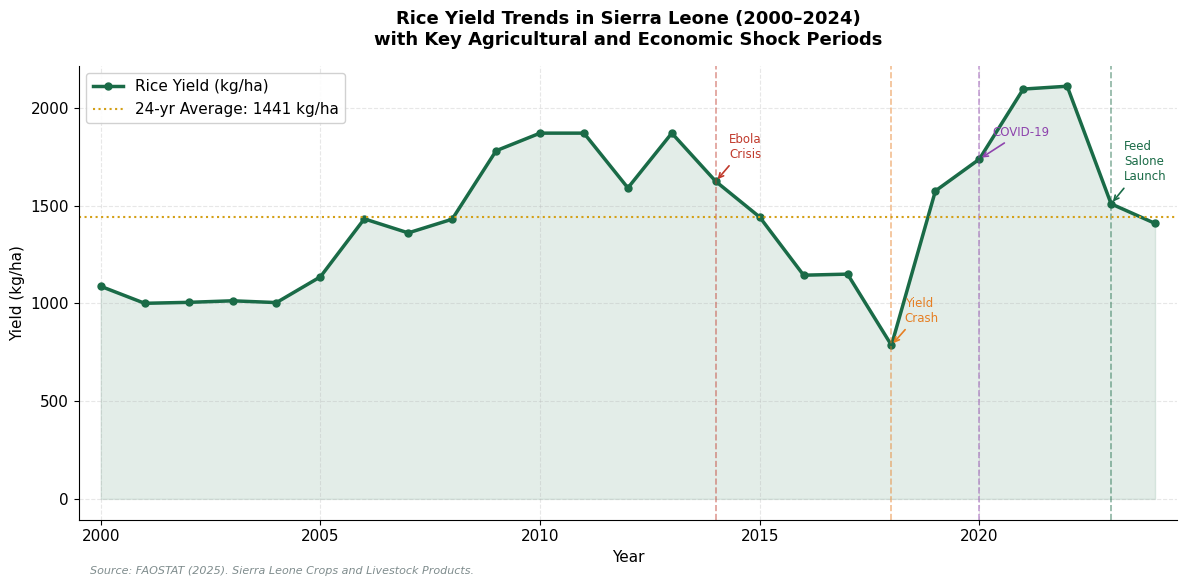

In [4]:
from src import visualization as viz
fig = viz.plot_rice_yield_trend(analysis)
plt.show()

## 4. EDA — Figure 2: Multi-Crop Yield Comparison

[✓] Figure saved: fig2_multi_crop_yields


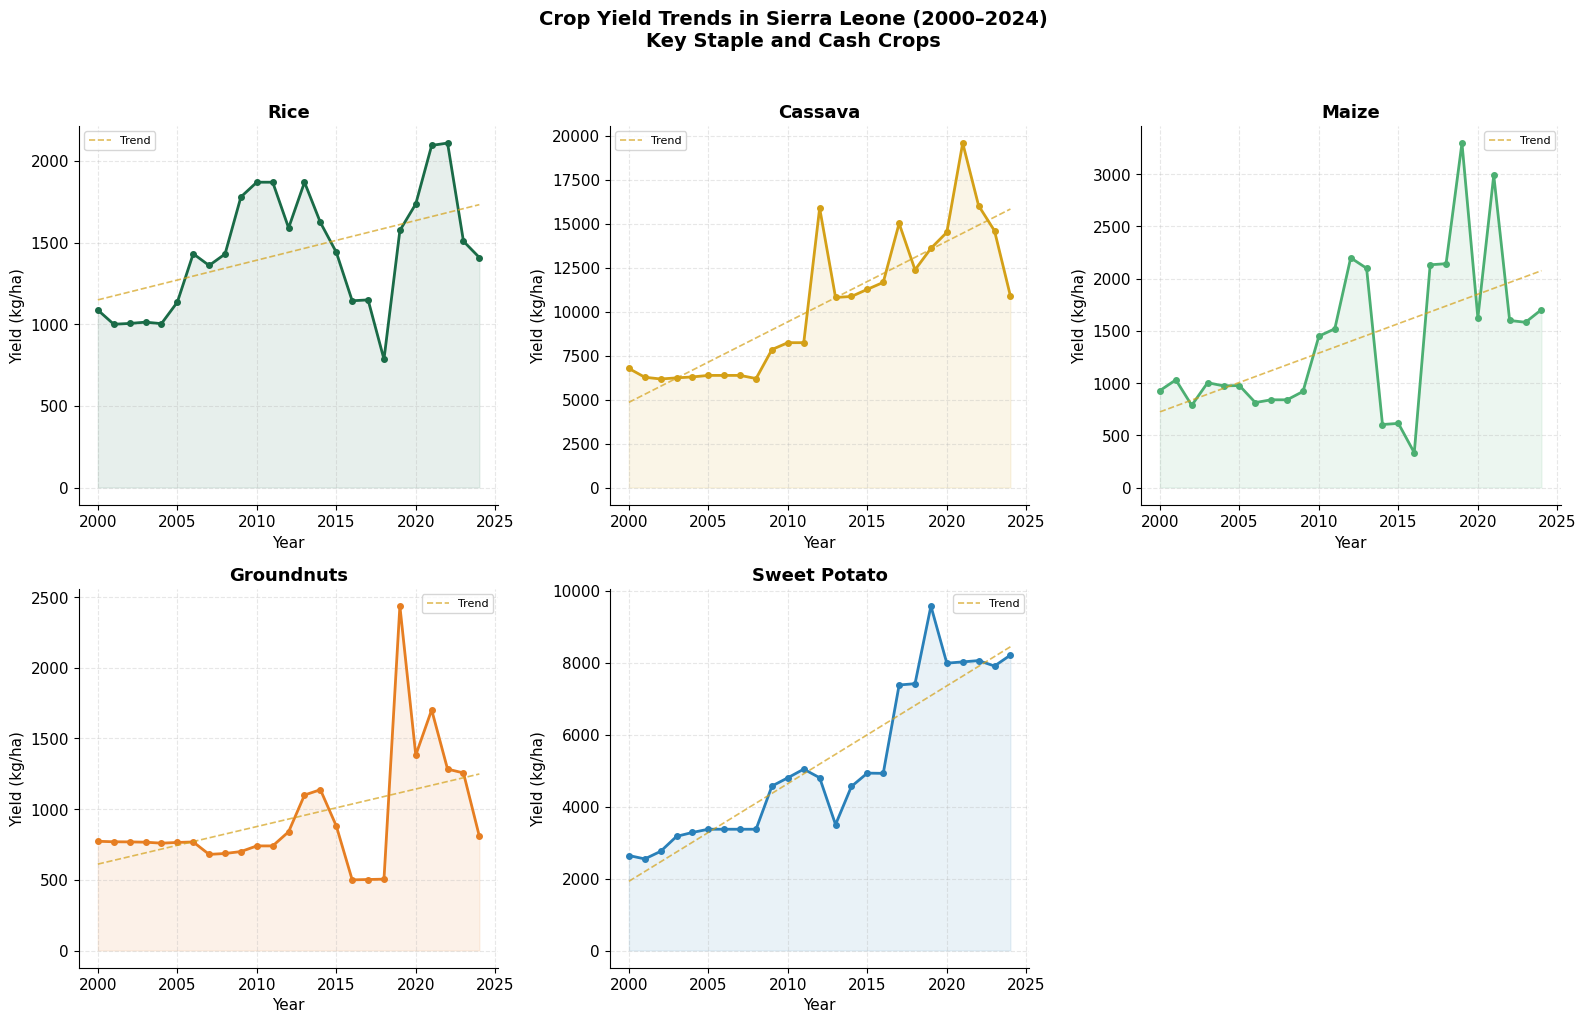

In [5]:
fig = viz.plot_multi_crop_yield(analysis)
plt.show()

## 5. Yield Summary Statistics

In [6]:
yield_cols = [c for c in analysis.columns if c.endswith('_Yield')]
summary = analysis[['Year'] + yield_cols].describe().T
summary.columns = ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
summary = summary.round(2)
summary.to_csv('outputs/reports/yield_summary_statistics.csv')
print('[saved] outputs/reports/yield_summary_statistics.csv')
summary

[saved] outputs/reports/yield_summary_statistics.csv


,Count,Mean,Std,Min,25%,50%,75%,Max
Year,25.00,2012.00,7.36,2000.00,2006.00,2012.00,2018.00,2024.00
"Broad beans and horse beans, dry_Yield",25.00,1014.97,198.23,498.60,885.90,979.20,1200.00,1250.00
Cabbages_Yield,2.00,6696.55,146.30,6593.10,6644.83,6696.55,6748.28,6800.00
"Cashew nuts, in shell_Yield",2.00,207.10,0.42,206.80,206.95,207.10,207.25,207.40
Cassava_Yield,25.00,10331.55,3995.37,6166.20,6370.00,10800.00,13590.50,19572.70
Cereals n.e.c._Yield,25.00,819.60,42.58,785.70,800.00,806.70,809.90,978.50
"Cereals, primary_Yield",25.00,1374.10,316.59,813.00,1092.30,1350.90,1630.00,1929.40
"Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw_Yield",25.00,3508.22,968.66,2200.00,2494.50,3952.80,4384.10,5000.00
"Chillies and peppers, green (Capsicum spp. and Pimenta spp.)_Yield",7.00,1426.51,399.80,786.10,1279.65,1463.00,1531.05,2115.10
Cocoa beans_Yield,25.00,385.71,64.39,275.00,360.00,368.40,405.40,599.60
